In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import requests

import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

from tqdm.auto import tqdm

from transformers import GPT2Tokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [47]:
# model_name = 'gpt2'
model_name = 'gpt2-large'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

model.eval()

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)

# Import text from Wikpedia and tokenize

In [48]:
url = "https://en.wikipedia.org/wiki/Light-emitting_diode"
header = {"user-Agent": 'Mozilla/5.0'}
response = requests.get(url, headers=header)

start_pos = start_string = 'mw-body-content'
end_string = 'id="References"'

start_pos = response.text.find(start_string)
end_pos = response.text.find(end_string)

text = response.text[start_pos:end_pos]

print(f'Original text has {len(response.text):,} chars')
print(f'Extracted text has {len(text):,} chars')

# Tokenize
tokens = tokenizer(text)

print(f'Tokenized text has {len(tokens["input_ids"]):,} tokens')


Original text has 538,522 chars
Extracted text has 170,994 chars
Tokenized text has 55,897 tokens


In [49]:
from collections import Counter

top_tokens = Counter(tokens["input_ids"]).most_common(10)

for tok, cnt in top_tokens:
    print(f'Token "{tokenizer.decode(tok):5}" occurs {cnt:>5} times')

Token "-    " occurs  2437 times
Token "="   " occurs  2088 times
Token "a    " occurs  1421 times
Token "_    " occurs  1385 times
Token "</   " occurs  1252 times
Token "/    " occurs  1228 times
Token ""    " occurs  1222 times
Token ">    " occurs  1191 times
Token "span " occurs  1064 times
Token "">   " occurs   970 times


In [50]:
# Create batches of shape (10,1024)
sequence_length = 1024
stride = 256
max_batches = 10

ids = torch.tensor(tokens["input_ids"], dtype=torch.long)

windows = []
for start in range(0, len(ids) - sequence_length + 1, stride):
    windows.append(ids[start:start + sequence_length])
    if len(windows) == max_batches:
        break

input_ids = torch.stack(windows).to(device)
attention_mask = torch.ones_like(input_ids).to(device)

print("input_ids.shape:", input_ids.shape)
print("attention_mask.shape:", attention_mask.shape)

input_ids.shape: torch.Size([10, 1024])
attention_mask.shape: torch.Size([10, 1024])


# Implant hooks

In [51]:
activations = {}
def hook(layeri):
  def implant_hook(module, input, output):
    activations[f'mlp_{layeri}'] = output.detach().cpu().numpy()
    return None
  return implant_hook

if "hh" in globals():
  for h in hh:
    h.remove()

num_layers = model.config.n_layer

hh = []
for layeri in range(num_layers):
  hh.append(model.transformer.h[layeri].mlp.register_forward_hook(hook(layeri)))

# Run the model on the tokens

In [52]:
with torch.no_grad():
  outputs = model(input_ids=input_ids, attention_mask=attention_mask)

In [53]:
activations['mlp_0'].shape

(10, 1024, 1280)

# Create an Autoencoder model

In [54]:
def createSAE(input_dim, num_latent):

  # Create a class for an autoencoder
  class SparseAE(nn.Module):
    def __init__(self, input_dim, latent_dim, k=None, sparsity_weight=1, decorrelation_weight=.0005):
      super().__init__()
      self.sparsity_weight = sparsity_weight
      self.decorrelation_weight = decorrelation_weight

      self.encode = nn.Linear(input_dim, latent_dim, bias=False)

      # k-sparse parameter (default: 50% of input)
      if k is None:
        self.k = input_dim // 2
      else:
        self.k = k

    # Forward pass
    def forward(self,x):

      # Pass through RELU activation
      latent = F.relu(self.encode(x))

      # "k-sparsify": force spacify by zeroing out small activation values
      # Fix: Use values[:, -1] to get the k-th largest value for each row/sample
      topk_vals = torch.topk(latent, self.k, dim=1, largest=True, sorted=True).values[:, -1].unsqueeze(dim=1)
      latent_sparse = torch.where(latent < topk_vals, 0, latent)

      # Pass the masked latent values through decoder (transpsoed encoder)
      y = F.linear(latent_sparse, self.encode.weight.t())

      return y, latent_sparse

    # Sparsity Loss
    def sparsity_loss(self, z):
      return self.sparsity_weight * torch.mean(torch.abs(z))

    # Penalty on inter-latent covariance
    def decorrelation_loss(self, z):
      z_cov = torch.cov(z.T)
      off_diag = z_cov - torch.diag(torch.diag(z_cov))
      decor_loss = self.decorrelation_weight * (torch.sum(off_diag ** 2))
      return decor_loss

  # Create an instance of the autoencoder
  sae = SparseAE(input_dim=input_dim, latent_dim=num_latent, k=num_latent//3)
  return sae.to(device)

In [55]:
# test the function

num_hidden = activations['mlp_3'].shape[-1]
X = torch.tensor(activations['mlp_3']).view(-1, num_hidden).to(device)

# Create an SAE model with 2xexpansion
sae = createSAE(input_dim=num_hidden, num_latent=num_hidden*2)

# Push the model
with torch.no_grad():
  y, latent_sparse = sae(X)

# Train the model

In [56]:
from math import isnan
# Initialize
num_layers = model.config.n_layer
num_hidden = model.config.n_embd

final_loss = np.zeros(num_layers)
latent_density = np.zeros(num_layers)
density_activations = np.zeros(num_layers)

num_epochs = 75

# Loop over layers
for layeri in tqdm(range(num_layers), desc="Running Layer", leave=False, colour='blue', position=0):
  X = torch.tensor(activations[f'mlp_{layeri}'][:,1:]).view(-1, num_hidden).to(device)
  sae = createSAE(input_dim=num_hidden, num_latent=num_hidden*2)

  # Optimizer and Loss functions
  optimizer = optim.Adam(sae.parameters(), lr=1e-3)
  mse_loss = nn.MSELoss()

  # Training loop
  for epoch in tqdm(range(num_epochs), desc="Running Epoch", leave=False, colour='green', position=1, bar_format='  {l_bar}{bar}{r_bar}'):
    # Removed with torch.no_grad(): from here to allow gradient computation
    y, latent = sae(X)

    loss = mse_loss(y, X) + sae.sparsity_loss(latent) + sae.decorrelation_loss(latent)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # Capture final loss
  final_loss[layeri] = loss.item()

  # final run to get the latent activations
  with torch.no_grad():
    y, latent = sae(X)

  latent = latent.cpu().numpy()

  # Get latent layer characterisitics

  # mask for zero-valued activations
  density_mask = np.where(latent==0,np.nan,1)

  # Calculate density percentage of latent layer (percentage of non_zero values)
  density_component = 100 * np.mean(latent != 0)
  latent_density[layeri] = density_component

  # Calculate the activations density per component
  non_zero_act_temp = np.abs(latent * density_mask)
  non_zero_act_temp = np.where(np.isnan(non_zero_act_temp), 0, non_zero_act_temp)
  non_zero_act = np.nanmean(non_zero_act_temp, axis=0)

  # Min-max scale both the density component and non_zero_act robustly

  # Scale against the range of latent_density values accumulated so far
  current_latent_densities = latent_density[:layeri+1]
  dpc_min_val = np.nanmin(current_latent_densities) # Use nanmin
  dpc_max_val = np.nanmax(current_latent_densities) # Use nanmax
  if np.isnan(dpc_min_val) or (dpc_max_val == dpc_min_val):
      dpc = 0.0
  else:
      dpc = (density_component - dpc_min_val) / (dpc_max_val - dpc_min_val)

  # Robust scaling for non_zero_act (nza)
  nza_min_val = np.nanmin(non_zero_act) # Use nanmin
  nza_max_val = np.nanmax(non_zero_act) # Use nanmax
  if np.isnan(nza_min_val) or (nza_max_val == nza_min_val):
      nza = np.zeros_like(non_zero_act)
  else:
      nza = (non_zero_act - nza_min_val) / (nza_max_val - nza_min_val)

  density_activations[layeri] = np.mean(dpc * nza)

Running Layer:   0%|          | 0/36 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

...

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

  Running Epoch:   0%|          | 0/75 [00:00<?, ?it/s]

# Plot the results

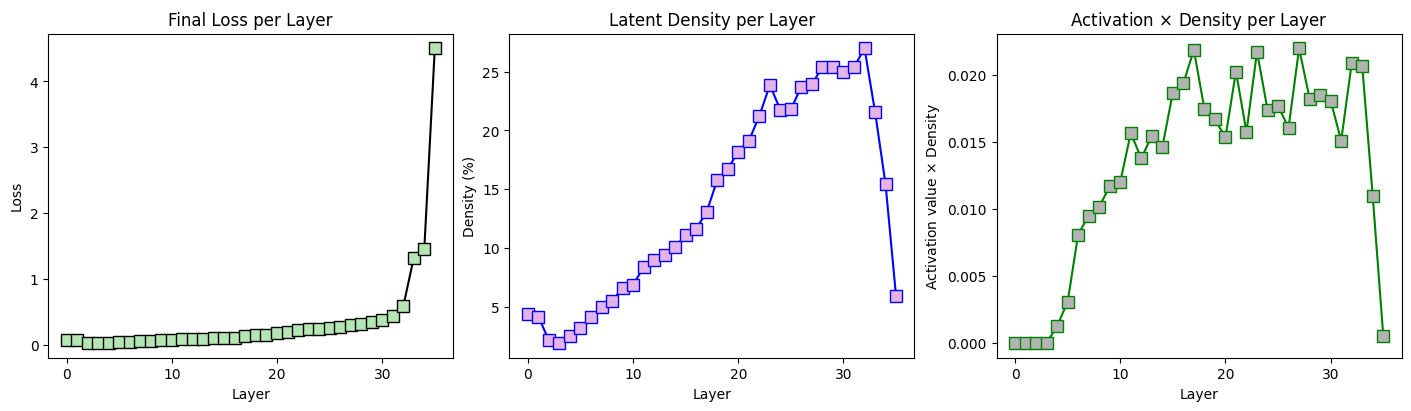

In [59]:
fig, axs = plt.subplots(1,3,figsize=(14,4),layout='constrained')

for ax in axs:
  ax.set_xticks(np.arange(0,num_layers,10))

axs[0].plot(final_loss, 'ks-', mfc=[.7,.9,.7,1], ms=9)
axs[0].set(xlabel='Layer', ylabel='Loss', title='Final Loss per Layer')

axs[1].plot(latent_density, 'bs-', mfc=[.9,.7,.9,1], ms=9)
axs[1].set(xlabel='Layer', ylabel='Density (%)', title='Latent Density per Layer')

axs[2].plot(density_activations, 'gs-', mfc=[.7,.7,.7,1], ms=9)
axs[2].set(xlabel='Layer', ylabel='Activation value $\\times$ Density', title='Activation $\\times$ Density per Layer')


plt.show()
